In [21]:
print("Jupyter работает! 🎉")

Jupyter работает! 🎉


In [2]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [3]:
!pip install pandas matplotlib yfinance --quiet



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import yfinance as yf

print("Библиотеки загружены ✅")


Библиотеки загружены ✅


In [5]:
# Загрузим состав индекса NASDAQ-100
nasdaq = yf.Ticker("^NDX")

# Получим компоненты (состав)
components = nasdaq.constituents

# Посмотрим первые строки таблицы
components.head()


AttributeError: 'Ticker' object has no attribute 'constituents'

In [ ]:
url = "https://en.wikipedia.org/wiki/NASDAQ-100"
tables = pd.read_html(url)
nasdaq_table = tables[3]  # 4-я таблица на странице (в ней состав)
nasdaq_table.head()

HTTPError: HTTP Error 403: Forbidden

In [6]:
!pip install lxml



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
pip install html5lib beautifulsoup4


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/NASDAQ-100"

# Укажем заголовок браузера
headers = {'User-Agent': 'Mozilla/5.0'}

# Получаем HTML-страницу вручную
html = requests.get(url, headers=headers).text

# Читаем таблицы
tables = pd.read_html(html)

# Проверим, сколько таблиц нашлось
len(tables)


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\3451503690.py:13: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


19

In [9]:
for i, table in enumerate(tables):
    print(f"Таблица {i} имеет форму {table.shape}")

Таблица 0 имеет форму (11, 2)
Таблица 1 имеет форму (2, 3)
Таблица 2 имеет форму (26, 3)
Таблица 3 имеет форму (41, 4)
Таблица 4 имеет форму (101, 4)
Таблица 5 имеет форму (218, 6)
Таблица 6 имеет форму (1, 2)
Таблица 7 имеет форму (4, 3)
Таблица 8 имеет форму (35, 2)
Таблица 9 имеет форму (2, 2)
Таблица 10 имеет форму (4, 2)
Таблица 11 имеет форму (6, 2)
Таблица 12 имеет форму (5, 2)
Таблица 13 имеет форму (2, 2)
Таблица 14 имеет форму (3, 2)
Таблица 15 имеет форму (5, 2)
Таблица 16 имеет форму (2, 2)
Таблица 17 имеет форму (1, 2)
Таблица 18 имеет форму (8, 2)


In [10]:
tables[3].head()

,Year,Closing level,Change in Index in Points,Change in Index in %
0,1985,132.29,NaN,NaN
1,1986,141.41,9.12,6.89
2,1987,156.25,14.84,10.49
3,1988,177.41,21.16,13.54
4,1989,223.84,46.43,26.17


In [11]:
tables[4].head()

,Ticker,Company,ICB Industry[14],ICB Subsector[14]
0,ADBE,Adobe Inc.,Technology,Computer Software
1,AMD,Advanced Micro Devices,Technology,Semiconductors
2,ABNB,Airbnb,Consumer Discretionary,Diversified Commercial Services
3,ALNY,Alnylam Pharmaceuticals,Health Care,Biotechnology
4,GOOGL,Alphabet Inc. (Class A),Technology,Computer Software


In [12]:
nasdaq_100 = tables[4]

# Быстрый взгляд на данные
nasdaq_100.head()


,Ticker,Company,ICB Industry[14],ICB Subsector[14]
0,ADBE,Adobe Inc.,Technology,Computer Software
1,AMD,Advanced Micro Devices,Technology,Semiconductors
2,ABNB,Airbnb,Consumer Discretionary,Diversified Commercial Services
3,ALNY,Alnylam Pharmaceuticals,Health Care,Biotechnology
4,GOOGL,Alphabet Inc. (Class A),Technology,Computer Software


In [13]:
# Удалим возможные дубли
nasdaq_100 = nasdaq_100.drop_duplicates()

# Убедимся, что названия столбцов чистые
nasdaq_100.columns = nasdaq_100.columns.str.strip()

# Проверим, что всё выглядит корректно
nasdaq_100.info()
nasdaq_100.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Ticker             101 non-null    object
 1   Company            101 non-null    object
 2   ICB Industry[14]   101 non-null    object
 3   ICB Subsector[14]  101 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


,Ticker,Company,ICB Industry[14],ICB Subsector[14]
0,ADBE,Adobe Inc.,Technology,Computer Software
1,AMD,Advanced Micro Devices,Technology,Semiconductors
2,ABNB,Airbnb,Consumer Discretionary,Diversified Commercial Services
3,ALNY,Alnylam Pharmaceuticals,Health Care,Biotechnology
4,GOOGL,Alphabet Inc. (Class A),Technology,Computer Software


In [14]:
nasdaq_100.to_csv("nasdaq_100.csv", index=False, encoding="utf-8")


In [15]:
!pip install plotly
import plotly.express as px


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


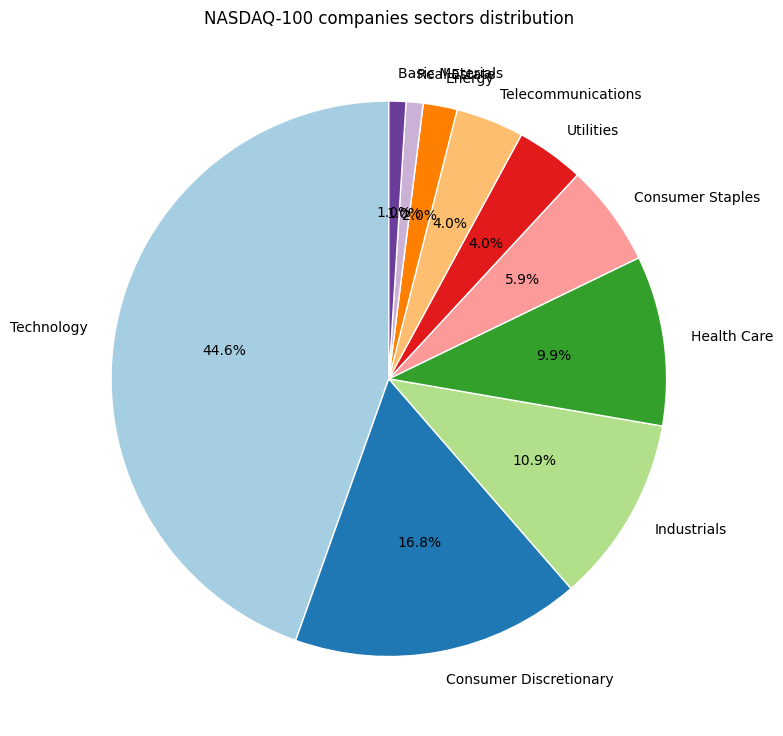

In [16]:
import matplotlib.pyplot as plt

# Подсчёт количества компаний в каждом секторе
sector_counts = nasdaq_100["ICB Industry[14]"].value_counts()

# Цветовая палитра (автоматическая, но мягкая)
colors = plt.cm.Paired(range(len(sector_counts)))

# Построение круговой диаграммы
plt.figure(figsize=(8, 8))
plt.pie(
    sector_counts,
    labels=sector_counts.index,
    autopct="%1.1f%%",      # подпись процентов
    startangle=90,          # поворот, чтобы начало было сверху
    colors=colors,
    wedgeprops={"edgecolor": "white"}  # аккуратные границы
)
plt.title("NASDAQ-100 companies sectors distribution")
plt.tight_layout()
plt.show()


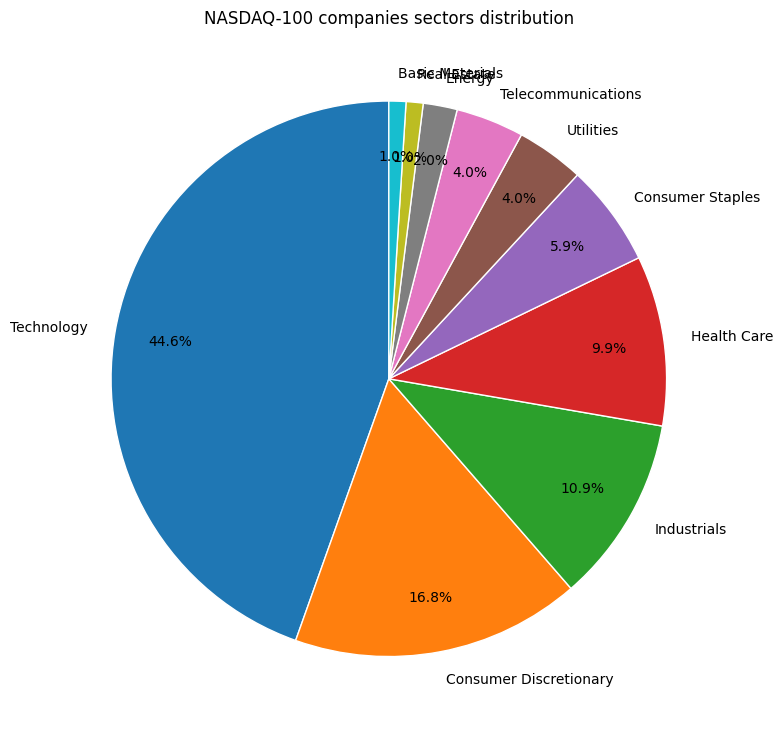

In [17]:
plt.figure(figsize=(8, 8))
plt.pie(
    sector_counts,
    labels=sector_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"},
    labeldistance=1.1,    # расстояние подписи от центра
    pctdistance=0.8        # расстояние процента от центра
)
plt.title("NASDAQ-100 companies sectors distribution")
plt.tight_layout()
plt.show()


In [18]:
import plotly.express as px

fig = px.pie(
    names=sector_counts.index,
    values=sector_counts.values,
    title="NASDAQ-100 companies sectors distribution",
    hole=0.3
)
fig.show()


In [19]:
import plotly.express as px
import plotly.io as pio

# Устанавливаем вывод графика в браузер
pio.renderers.default = "browser"

fig = px.pie(
    names=sector_counts.index,
    values=sector_counts.values,
    title="NASDAQ-100 companies sectors distribution",
    hole=0.3
)
fig.show()


In [20]:
import plotly.express as px

# создаём диаграмму на основе данных
fig = px.pie(
    names=sector_counts.index,
    values=sector_counts.values,
    title="NASDAQ-100 companies sectors distribution",
    hole=0.3
)

# настраиваем внешний вид и поведение графика
fig.update_traces(
    textposition='outside',              # выносит подписи за пределы кругов
    textinfo='label+percent',            # показывает имя сектора и процент
    pull=[0.05 if i < 3 else 0 for i in range(len(sector_counts))],  # слегка выдвигаем топ-3 сектора
    marker=dict(line=dict(color='white', width=3)),  # белые границы между секторами
    textfont=dict(size=14),              # размер шрифта подписей
    hoverinfo='skip'                     # 🔹 отключает всплывающие подсказки
)

# общие настройки оформления (layout)
fig.update_layout(
    title_font=dict(size=22),            # размер шрифта заголовка
    legend_title_text='Секторы',         # заголовок легенды
    showlegend=True,                     # показывать легенду
    legend=dict(x=1.05, y=0.5),          # позиция легенды (справа, по центру)
    paper_bgcolor='rgba(250,250,250,1)', # светлый фон (чуть теплее белого)
    margin=dict(t=60, b=60, l=60, r=120) # отступы от краёв графика
)

# показать диаграмму
fig.show()

# сохранить изображение для портфолио
fig.write_image("nasdaq_sector_distribution.png", scale=3)


In [22]:
import plotly.express as px

# переименовываем длинные сектора
rename = {
    "Technology": "Tech"
}
names = [rename.get(s, s) for s in sector_counts.index]

# создаём диаграмму
fig = px.pie(
    names=names,
    values=sector_counts.values,
    title="NASDAQ-100 companies sectors distribution",
    hole=0.3
)

# настройка внешнего вида
fig.update_traces(
    textposition='outside',               # подписи снаружи
    textinfo='label+percent',             # показываем имя + процент
    pull=[0.05 if i < 3 else 0 for i in range(len(sector_counts))],
    marker=dict(line=dict(color='white', width=3)),  # белые разделители
    textfont=dict(size=14),
    hoverinfo='skip'                      # отключаем всплывающие подсказки
)

# смещаем легенду правее, увеличиваем отступ
fig.update_layout(
    title_font=dict(size=22),
    legend_title_text='Секторы',
    showlegend=True,
    legend=dict(x=1.3, y=0.5),            # 👈 сдвиг легенды ещё правее
    paper_bgcolor='rgba(250,250,250,1)',  # тёплый белый фон
    margin=dict(t=60, b=60, l=60, r=260)  # увеличен правый отступ
)

fig.show()

# сохраняем для портфолио
fig.write_image("nasdaq_sector_distribution.png", scale=3)


In [23]:
import plotly.express as px

# короткие названия
rename = {"Technology": "Tech"}
names = [rename.get(s, s) for s in sector_counts.index]

# создаём диаграмму
fig = px.pie(
    names=names,
    values=sector_counts.values,
    title="NASDAQ-100 companies sectors distribution",
    hole=0.3,
    color_discrete_sequence=[
        "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
        "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#A0CBE8"
    ]  # умеренная аналитическая палитра
)

# настройки подписей и внешнего вида
fig.update_traces(
    textposition='outside',
    textinfo='label+percent',
    pull=[0.05 if i < 3 else 0 for i in range(len(sector_counts))],
    marker=dict(line=dict(color='white', width=3)),
    textfont=dict(size=14, color="#2E2E2E"),
    hoverinfo='skip'
)

# оформление
fig.update_layout(
    title_font=dict(size=22, color="#2E2E2E"),
    legend_title_text='Секторы',
    showlegend=True,
    legend=dict(
        x=1.3, y=0.5,
        font=dict(size=13, color="#2E2E2E")
    ),
    paper_bgcolor='rgba(240,240,240,1)',  # 👈 мягкий светло-серый фон
    plot_bgcolor='rgba(240,240,240,1)',
    margin=dict(t=60, b=60, l=60, r=260)
)

fig.show()

# сохраняем
fig.write_image("nasdaq_sector_distribution_soft_gray.png", scale=3)


In [25]:
!pip install -U kaleido


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
import os
print(os.getcwd())

c:\Users\olga\Documents\InvestmentDashboard\notebooks


In [26]:

import plotly.express as px

# короткие названия
rename = {"Technology": "Tech"}
names = [rename.get(s, s) for s in sector_counts.index]

# создаём диаграмму
fig = px.pie(
    names=names,
    values=sector_counts.values,
    title="NASDAQ-100 companies sectors distribution",
    hole=0.3,
    color_discrete_sequence=[
        "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
        "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#A0CBE8"
    ]
)

# настройки внешнего вида
fig.update_traces(
    textposition='outside',
    textinfo='label+percent',
    pull=[0.005 if i < 3 else 0 for i in range(len(sector_counts))],  # 👈 мягкий вылет
    marker=dict(line=dict(color='white', width=3)),
    textfont=dict(size=14, color="#2E2E2E"),
    hoverinfo='skip'
)

# оформление
fig.update_layout(
    title_font=dict(size=22, color="#2E2E2E"),
    legend_title_text='Sectors',
    showlegend=True,
    legend=dict(
        x=1.3, y=0.5,
        font=dict(size=13, color="#2E2E2E")
    ),
    paper_bgcolor='rgba(224,224,224,1)',  # 👈 фон темнее (E0E0E0)
    plot_bgcolor='rgba(224,224,224,1)',
    margin=dict(t=60, b=60, l=60, r=260)
)

fig.show()

# сохранить для портфолио
fig.write_image("nasdaq_sector_distribution_darkgray.png", scale=3)


In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Загружаем данные по ETF NASDAQ-100 — тикер QQQ
data = yf.download("QQQ", start="2015-01-01", end="2025-01-01")

#  Рассчитываем дневную доходность
data['Daily Return'] = data['Adj Close'].pct_change()

#  Среднегодовая доходность (через среднедневную)
annual_return = data['Daily Return'].mean() * 252 * 100  # 252 торговых дня
#  Среднегодовая волатильность
annual_volatility = data['Daily Return'].std() * np.sqrt(252) * 100
#  Коэффициент Шарпа (доходность / риск), без учёта безрисковой ставки
sharpe_ratio = annual_return / annual_volatility

#  Выводим сводку
print("📊 Показатели NASDAQ-100 (QQQ) за 2015–2025:")
print(f"Среднегодовая доходность: {annual_return:.2f}%")
print(f"Среднегодовая волатильность: {annual_volatility:.2f}%")
print(f"Коэффициент Шарпа: {sharpe_ratio:.2f}")

#  Строим график динамики индекса
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Adj Close'], label='QQQ (NASDAQ-100)')
plt.title("Динамика NASDAQ-100 (QQQ) за 2015–2025 гг.")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2175275141.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


KeyError: 'Adj Close'

In [33]:
import yfinance as yf

data = yf.download("QQQ", start="2015-01-01", end="2025-01-01")
print(data.head())
print(data.columns)


C:\Users\olga\AppData\Local\Temp\ipykernel_36056\2263266827.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker            QQQ        QQQ        QQQ        QQQ       QQQ
Date                                                            
2015-01-02  94.906532  96.068196  94.445552  95.662539  31314600
2015-01-05  93.514381  94.602294  93.247012  94.491657  36521300
2015-01-06  92.260521  93.809414  91.845642  93.652682  66205500
2015-01-07  93.449821  93.671090  92.647714  92.868989  37577400
2015-01-08  95.238449  95.422838  94.141315  94.242731  40212600
MultiIndex([( 'Close', 'QQQ'),
            (  'High', 'QQQ'),
            (   'Low', 'QQQ'),
            (  'Open', 'QQQ'),
            ('Volume', 'QQQ')],
           names=['Price', 'Ticker'])


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\299557418.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


📊 NASDAQ-100 (QQQ) Performance 2015–2025:
Average annual return: 19.23%
Average annual volatility: 21.82%
Sharpe Ratio: 0.88


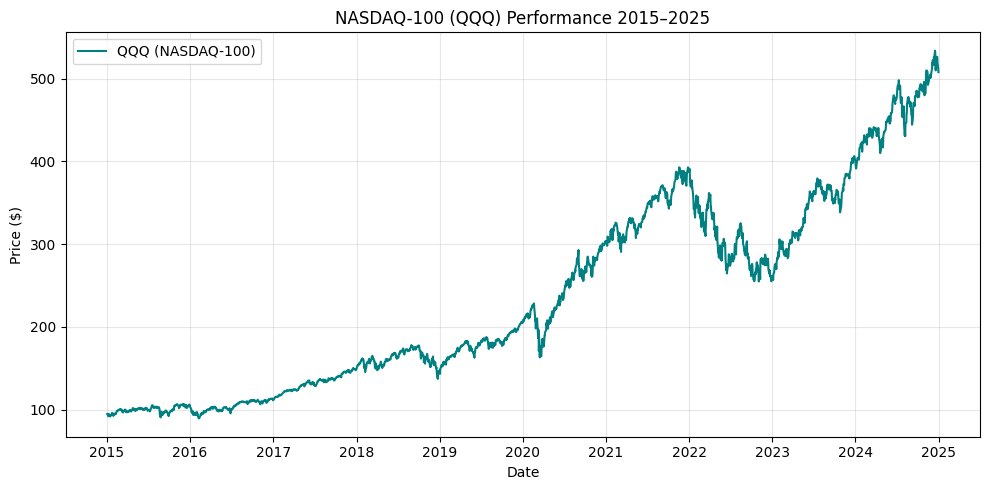

In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загружаем данные NASDAQ-100 (ETF QQQ)
data = yf.download("QQQ", start="2015-01-01", end="2025-01-01")

# Если таблица многоуровневая — упрощаем
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Проверяем наличие нужных колонок
if 'Adj Close' in data.columns:
    price_col = 'Adj Close'
else:
    price_col = 'Close'

# Рассчитываем дневную доходность
data['Daily Return'] = data[price_col].pct_change()

# Среднегодовая доходность и волатильность
annual_return = data['Daily Return'].mean() * 252 * 100
annual_volatility = data['Daily Return'].std() * np.sqrt(252) * 100
sharpe_ratio = annual_return / annual_volatility

# Выводим результаты
print("📊 NASDAQ-100 (QQQ) Performance 2015–2025:")
print(f"Average annual return: {annual_return:.2f}%")
print(f"Average annual volatility: {annual_volatility:.2f}%")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# График динамики
plt.figure(figsize=(10, 5))
plt.plot(data.index, data[price_col], label='QQQ (NASDAQ-100)', color='teal')
plt.title("NASDAQ-100 (QQQ) Performance 2015–2025")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2416754927.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed

📊 Comparison of Indexes 2015–2025


,"Average annual return, %","Average annual volatility, %",Sharpe Ratio
Ticker,,,
DIA,12.35,17.46,0.71
QQQ,19.23,21.82,0.88
SPY,13.81,17.62,0.78


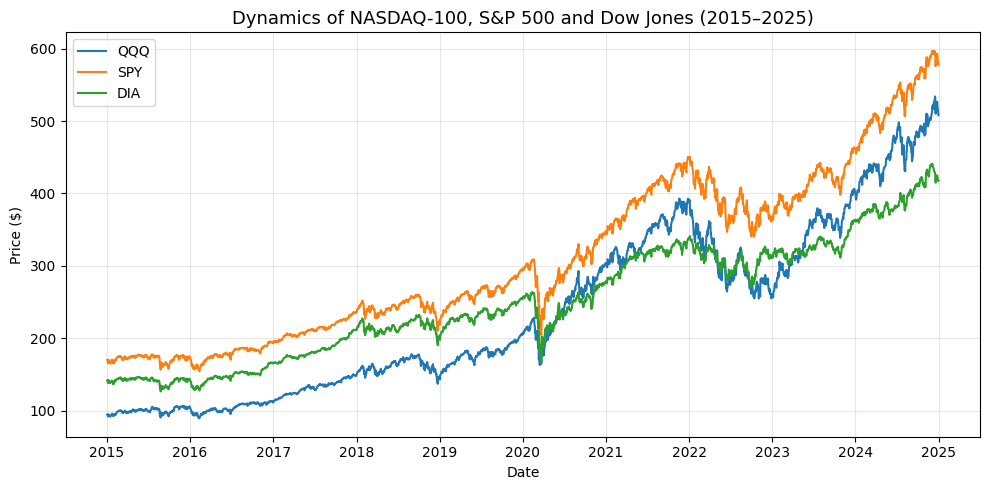

C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2416754927.py:44: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2416754927.py:45: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



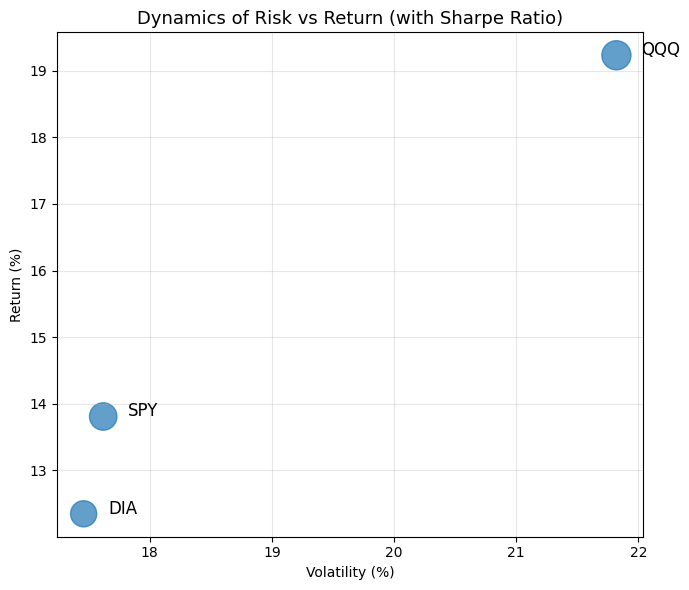

In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1. Загружаем данные для трёх индексов ===
tickers = ["QQQ", "SPY", "DIA"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]

# === 2. Рассчитываем дневные доходности ===
returns = data.pct_change().dropna()

# === 3. Вычисляем ключевые показатели ===
summary = pd.DataFrame({
    "Average annual return, %": (returns.mean() * 252 * 100).round(2),
    "Average annual volatility, %": (returns.std() * np.sqrt(252) * 100).round(2),
})
summary["Sharpe Ratio"] = (summary["Average annual return, %"] /
                           summary["Average annual volatility, %"]).round(2)
# === 4. Выводим результаты ===
print("📊 Comparison of Indexes 2015–2025")
display(summary)

# === 5. График динамики трёх индексов ===
plt.figure(figsize=(10, 5))
for ticker in tickers:
    plt.plot(data.index, data[ticker], label=ticker)
plt.title("Dynamics of NASDAQ-100, S&P 500 and Dow Jones (2015–2025)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# === 6. График 'риск ↔ доходность' ===
plt.figure(figsize=(7, 6))
plt.scatter(summary["Average annual volatility, %"],
            summary["Average annual return, %"],
            s=summary["Sharpe Ratio"] * 500,  # размер пузыря = Шарп
            alpha=0.7)

for i, ticker in enumerate(summary.index):
    plt.text(summary["Average annual volatility, %"][i] + 0.2,
             summary["Average annual return, %"][i],
             ticker, fontsize=12)

plt.title("Dynamics of Risk vs Return (with Sharpe Ratio)", fontsize=13)
plt.xlabel("Volatility (%)")
plt.ylabel("Return (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


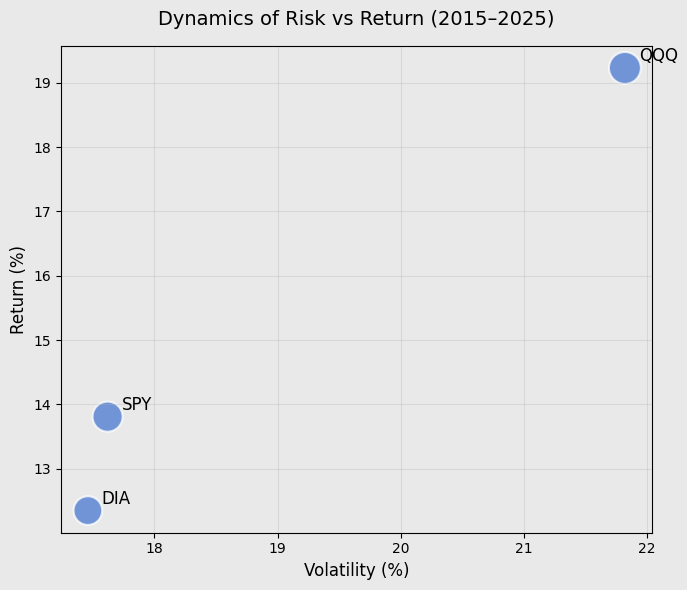

In [32]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')  # нейтральная цветовая палитра

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#e9e9e9')  # фон ближе к средне-серому
fig.patch.set_facecolor('#e9e9e9')

# пузырьковая диаграмма
ax.scatter(
    summary["Average annual volatility, %"],
    summary["Average annual return, %"],
    s=summary["Sharpe Ratio"] * 600,
    alpha=0.75,
    edgecolor='white',
    linewidth=1.5
)

# аккуратные аннотации
for i, ticker in enumerate(summary.index):
    ax.annotate(
        ticker,
        (summary["Average annual volatility, %"].iloc[i],
         summary["Average annual return, %"].iloc[i]),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=12,
        color='black',
        fontweight='medium'
    )

# оформление
ax.set_title("Dynamics of Risk vs Return (2015–2025)", fontsize=14, pad=15)
ax.set_xlabel("Volatility (%)", fontsize=12)
ax.set_ylabel("Return (%)", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


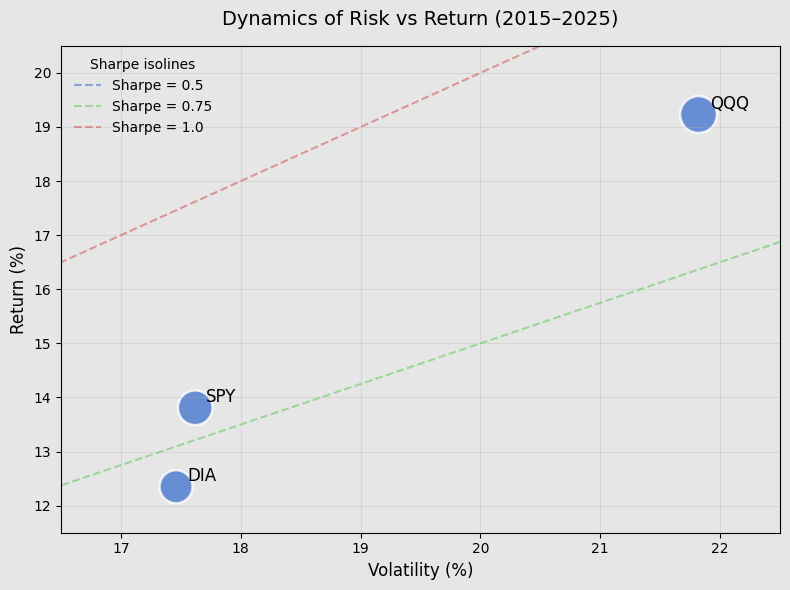

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('#e6e6e6')
fig.patch.set_facecolor('#e6e6e6')

# Основная пузырьковая диаграмма
ax.scatter(
    summary["Average annual volatility, %"],
    summary["Average annual return, %"],
    s=summary["Sharpe Ratio"] * 800,  # чуть больше размер для акцента
    alpha=0.8,
    edgecolor='white',
    linewidth=1.8
)

# Добавляем аннотации с линиями
for i, ticker in enumerate(summary.index):
    x = summary["Average annual volatility, %"].iloc[i]
    y = summary["Average annual return, %"].iloc[i]
    ax.annotate(
        ticker,
        xy=(x, y),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=12,
        color='black',
        fontweight='medium'
    )

# === Изолинии Шарпа ===
x_vals = np.linspace(15, 23, 200)
for sharpe in [0.5, 0.75, 1.0]:
    y_vals = sharpe * x_vals
    ax.plot(x_vals, y_vals, '--', label=f'Sharpe = {sharpe}', alpha=0.6)

# Подписи и оформление
ax.set_xlim(16.5, 22.5)
ax.set_ylim(11.5, 20.5)
ax.set_title("Dynamics of Risk vs Return (2015–2025)", fontsize=14, pad=15)
ax.set_xlabel("Volatility (%)", fontsize=12)
ax.set_ylabel("Return (%)", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(title="Sharpe isolines", loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


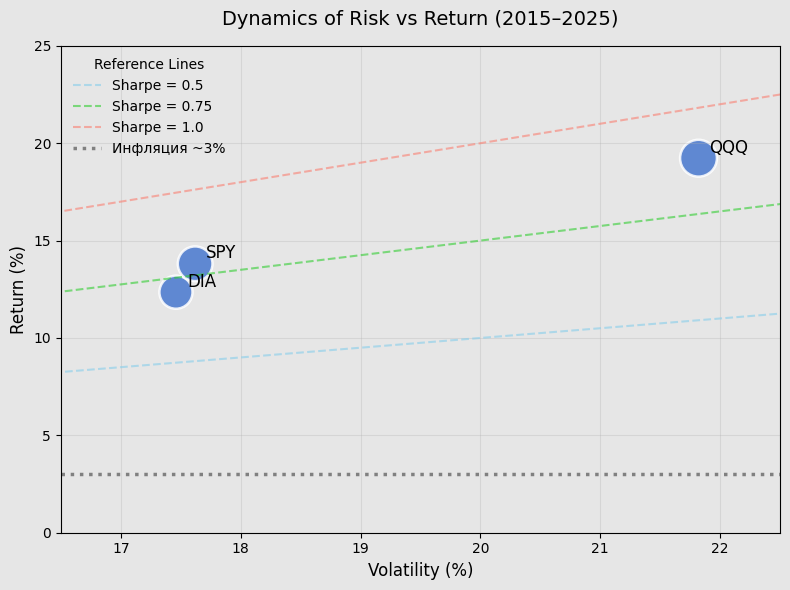

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('#e6e6e6')
fig.patch.set_facecolor('#e6e6e6')

# пузырьки
ax.scatter(
    summary["Average annual volatility, %"],
    summary["Average annual return, %"],
    s=summary["Sharpe Ratio"] * 800,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.8
)

# аннотации
for i, ticker in enumerate(summary.index):
    x = summary["Average annual volatility, %"].iloc[i]
    y = summary["Average annual return, %"].iloc[i]
    ax.annotate(
        ticker,
        xy=(x, y),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=12,
        color='black',
        fontweight='medium'
    )

# изолинии Шарпа
x_vals = np.linspace(15, 23, 200)
for sharpe, color in [(0.5, 'skyblue'), (0.75, 'limegreen'), (1.0, 'salmon')]:
    y_vals = sharpe * x_vals
    ax.plot(x_vals, y_vals, '--', label=f'Sharpe = {sharpe}', color=color, alpha=0.6)

# линия инфляции
inflation = 3
ax.axhline(y=inflation, color='gray', linestyle=':', linewidth=2.5, label='Инфляция ~3%')

# оформление
ax.set_xlim(16.5, 22.5)
ax.set_ylim(0, 25)
ax.set_title("Dynamics of Risk vs Return (2015–2025)", fontsize=14, pad=15)
ax.set_xlabel("Volatility (%)", fontsize=12)
ax.set_ylabel("Return (%)", fontsize=12)
ax.legend(title="Reference Lines", loc='upper left', frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


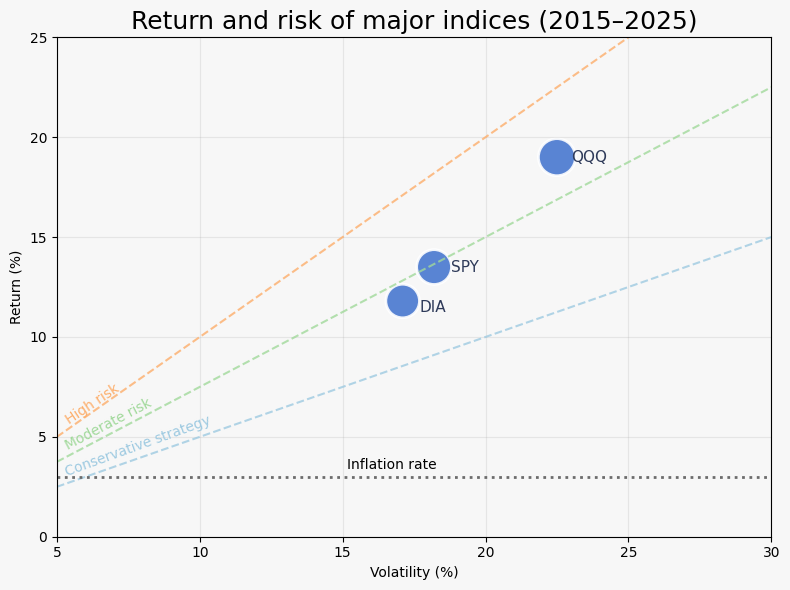

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- DATA (example, replace with your real data if needed) ----
summary = pd.DataFrame({
    "Average annual volatility, %": [22.5, 18.2, 17.1],
    "Average annual return, %": [19.0, 13.5, 11.8],
    "Sharpe ratio": [0.84, 0.74, 0.69]
}, index=["QQQ", "SPY", "DIA"])

# ---- PLOT ----
plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

ax.scatter(
    summary["Average annual volatility, %"],
    summary["Average annual return, %"],
    s=summary["Sharpe ratio"] * 850,
    alpha=0.9,
    edgecolor='white',
    linewidth=2
)

offsets = {
    "QQQ": (10, 0),
    "SPY": (12, 0),
    "DIA": (12, -5)
}

for i, ticker in enumerate(summary.index):
    x = summary["Average annual volatility, %"].iloc[i]
    y = summary["Average annual return, %"].iloc[i]
    dx, dy = offsets.get(ticker, (12, 0))
    ax.annotate(
        ticker,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=11,
        color='#2e3a59',
        fontweight='medium',
        ha='left',
        va='center'
    )

x_vals = np.linspace(5, 30, 200)
sharpe_lines = [
    (0.5, '#9ecae1', 'Conservative strategy'),
    (0.75, '#a1d99b', 'Moderate risk'),
    (1.0, '#fdae6b', 'High risk')
]

for sharpe, color, label in sharpe_lines:
    y_vals = sharpe * x_vals
    ax.plot(x_vals, y_vals, '--', color=color, alpha=0.8)
    angle = np.degrees(np.arctan((y_vals[-1] - y_vals[0]) / (x_vals[-1] - x_vals[0])))
    ax.text(
        x_vals[1] + 0.1,
        y_vals[1] + 0.5,
        label,
        color=color,
        fontsize=10,
        rotation=angle * 0.75
    )

inflation = 3
ax.axhline(y=inflation, color='#6c6c6c', linestyle=':', linewidth=2)
ax.text(15.15, inflation + 0.4, "Inflation rate", fontsize=10)

ax.set_xlim(5, 30)
ax.set_ylim(0, 25)
ax.set_title("Return and risk of major indices (2015–2025)", fontsize=18)
ax.set_xlabel("Volatility (%)")
ax.set_ylabel("Return (%)")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [36]:
import yfinance as yf
import pandas as pd
import numpy as np
import mplfinance as mpf

# === 1. Данные ===
data = yf.download("QQQ", start="2015-01-01", end="2025-01-01")
data.columns = data.columns.droplevel(1) if isinstance(data.columns, pd.MultiIndex) else data.columns

# === 2. Расчёты SMA и σ ===
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['STD_50'] = data['Close'].rolling(window=50).std()
data['Upper'] = data['SMA_50'] + data['STD_50']
data['Lower'] = data['SMA_50'] - data['STD_50']

# === 3. Сигналы ===
data['Position'] = np.nan
data.loc[data['Close'] < data['Lower'], 'Position'] = 1
data.loc[data['Close'] > data['Upper'], 'Position'] = -1
data['Position'] = data['Position'].ffill()

# === 4. Подготовка точек входа и выхода ===
buy_signals = data[data['Position'] == 1]
sell_signals = data[data['Position'] == -1]

# === 5. Настройка визуализации ===
sma_50 = mpf.make_addplot(data['SMA_50'], color='#4c72b0', width=1.2, linestyle='--', alpha=0.9)
upper = mpf.make_addplot(data['Upper'], color='#f28e2b', linestyle=':', alpha=0.8)
lower = mpf.make_addplot(data['Lower'], color='#59a14f', linestyle=':', alpha=0.8)
buy_markers = mpf.make_addplot(buy_signals['Close'], type='scatter', markersize=50, marker='^', color='#2ca02c')
sell_markers = mpf.make_addplot(sell_signals['Close'], type='scatter', markersize=50, marker='v', color='#d62728')

mpf.plot(
    data,
    type='candle',
    style='yahoo',
    title='Точки входа/выхода по SMA±σ — NASDAQ-100 (QQQ)',
    ylabel='Цена ($)',
    addplot=[sma_50, upper, lower, buy_markers, sell_markers],
    figsize=(14, 8),
    volume=False,
    tight_layout=True
)


ModuleNotFoundError: No module named 'mplfinance'

In [37]:
pip install mplfinance


     ---------------------------------------- 0.0/75.0 kB ? eta -:--:--
     -------------------- ----------------- 41.0/75.0 kB 960.0 kB/s eta 0:00:01
     -------------------------------------- 75.0/75.0 kB 689.1 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [38]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go

# === 1. Данные ===
data = yf.download("QQQ", start="2015-01-01", end="2025-01-01")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# === 2. Индикаторы ===
data['SMA_50'] = data['Close'].rolling(window=50).mean()
data['STD_50'] = data['Close'].rolling(window=50).std()
data['Upper'] = data['SMA_50'] + data['STD_50']
data['Lower'] = data['SMA_50'] - data['STD_50']

# === 3. График ===
fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'], high=data['High'], low=data['Low'], close=data['Close'],
    name='QQQ (NASDAQ-100)',
    increasing_line_color='#26a69a', decreasing_line_color='#ef5350'
))

fig.add_trace(go.Scatter(x=data.index, y=data['SMA_50'], name='SMA (50)', line=dict(color='royalblue', width=1.5)))
fig.add_trace(go.Scatter(x=data.index, y=data['Upper'], name='+1σ', line=dict(color='orange', dash='dot')))
fig.add_trace(go.Scatter(x=data.index, y=data['Lower'], name='-1σ', line=dict(color='orange', dash='dot')))

# === 4. Визуальные настройки ===
fig.update_layout(
    title='📈 Точки входа/выхода по SMA±σ — NASDAQ-100 (интерактивная версия)',
    xaxis_title='Дата',
    yaxis_title='Цена ($)',
    template='plotly_white',
    width=1200, height=700,
    hovermode='x unified',
    xaxis_rangeslider_visible=True,
    yaxis_fixedrange=False
)

# === 5. Подстройка диапазона оси Y ===
fig.update_yaxes(
    autorange=True,       # автоматическая подгонка по диапазону данных
    fixedrange=False,     # разрешаем вертикальный зум
    rangemode='tozero'    # чтобы ось не "висела" в воздухе при низких значениях
)
fig.update_layout(
    dragmode='zoom',             # включаем "zoom box"
    yaxis_fixedrange=False,      # разрешаем изменять масштаб по Y
)

# 🧠 трюк для автоадаптации по Y
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=3, label="3m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all", label="Все данные")
        ])
    )
)

fig.update_yaxes(
    autorange="reversed" if False else True,
    fixedrange=False,
    scaleratio=1,
    automargin=True
)

# === 6. Показ ===
fig.show()



C:\Users\olga\AppData\Local\Temp\ipykernel_154544\3293720654.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [39]:

import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# === 1) Загрузка данных NASDAQ-100 (ETF QQQ) ===
data = yf.download("QQQ", start="2015-01-01", end="2025-01-01")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# === 2) Расчет скользящих средних для стратегии «Три головы дракона» ===
data['SMA_9']  = data['Close'].rolling(9).mean()
data['SMA_21'] = data['Close'].rolling(21).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

# Сигналы: пересечение SMA_9 и SMA_21
data['Signal'] = np.where(data['SMA_9'] > data['SMA_21'], 1,
                   np.where(data['SMA_9'] < data['SMA_21'], -1, 0))
data['Cross'] = data['Signal'].diff()

buy = data[data['Cross'] == 2]   # точки покупок
sell = data[data['Cross'] == -2] # точки продаж

# === 3) Создание фигуры ===
fig = make_subplots(rows=1, cols=1)

# Свечной график: ч/б для профессионального вида
fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'], high=data['High'], low=data['Low'], close=data['Close'],
    increasing_line_color='#4a4a4a', decreasing_line_color='black',
    increasing_fillcolor='white',
    decreasing_fillcolor='#2e3a59',
    name='QQQ'
))

# Скользящие средние
fig.add_trace(go.Scatter(x=data.index, y=data['SMA_9'],  name='SMA 9',  line=dict(color='#59a14f', width=1.6)))
fig.add_trace(go.Scatter(x=data.index, y=data['SMA_21'], name='SMA 21', line=dict(color='#f28e2b', width=1.6)))
fig.add_trace(go.Scatter(x=data.index, y=data['SMA_50'], name='SMA 50', line=dict(color='#4c72b0', width=1.6, dash='dot')))

# Точки входа и выхода
fig.add_trace(go.Scatter(
    x=buy.index, y=buy['Close'], mode='markers', name='Покупка',
    marker=dict(symbol='triangle-up', color='#2ca02c', size=11, line=dict(width=1, color='black'))
))
fig.add_trace(go.Scatter(
    x=sell.index, y=sell['Close'], mode='markers', name='Продажа',
    marker=dict(symbol='triangle-down', color='#d62728', size=11, line=dict(width=1, color='black'))
))

# === 4) Визуальное оформление и UX ===
fig.update_layout(
    plot_bgcolor='#f7f7f7',
    paper_bgcolor='#f7f7f7',
    title=dict(
        text="Стратегия «Три головы дракона» — NASDAQ-100 (QQQ)",
        font=dict(size=20, color='#2e3a59', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=720,
    hovermode='x unified',
    dragmode='zoom',
    margin=dict(t=80, b=80, l=60, r=30),
    legend=dict(
        x=0.01, y=0.99, orientation='v',
        bgcolor='rgba(247,247,247,0.9)',
        bordercolor='#d0d0d0', borderwidth=1,
        font=dict(size=11)
    ),
    xaxis=dict(
        rangeslider=dict(visible=True),
        rangeselector=dict(visible=False)
    ),
    yaxis=dict(fixedrange=False)
)

# Автоматическая подстройка диапазона по оси Y
fig.update_yaxes(autorange=True)

# === 5) Подпись автора (для портфолио) ===
fig.add_annotation(
    text="Data analysis & visualization — Olga Mangileva",
    xref="paper", yref="paper",
    x=0.99, y=-0.38, showarrow=False,
    font=dict(size=12, color="#6c6c6c"),
    xanchor="right"
)

# === 6) Отображение ===
fig.show()



C:\Users\olga\AppData\Local\Temp\ipykernel_154544\1132024744.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [104]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime

# --- helpers ---
def fix_ticker(t):
    t = t.strip()
    # популярные кейсы wikipedia → yfinance
    t = t.replace('.', '-')   # BRK.B -> BRK-B, BF.B -> BF-B
    t = t.replace('/', '-')   # редкие
    return t

def get_constituents():
    # NASDAQ-100
    ndq = pd.read_html("https://en.wikipedia.org/wiki/Nasdaq-100")[3]  # таблица 4 обычно: 'Companies listed on the NASDAQ-100'
    nasdaq100 = sorted({fix_ticker(x) for x in ndq['Ticker'].astype(str)})

    # S&P 500
    sp = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
    sp500 = sorted({fix_ticker(x) for x in sp['Symbol'].astype(str)})

    # Dow Jones 30
    dj = pd.read_html("https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average")[1]
    dow30 = sorted({fix_ticker(x) for x in dj['Symbol'].astype(str)})

    return nasdaq100, sp500, dow30

nasdaq100, sp500, dow30 = get_constituents()

set_nq, set_sp, set_dj = set(nasdaq100), set(sp500), set(dow30)
overlap_all = (set_nq & set_sp) | (set_nq & set_dj) | (set_sp & set_dj)
overlap_3way = set_nq & set_sp & set_dj  # редко, но интересно

print(f"NASDAQ-100: {len(set_nq)} | S&P500: {len(set_sp)} | Dow30: {len(set_dj)}")
print(f"Пересечение (хотя бы два): {len(overlap_all)} | Пересечение всех трёх: {len(overlap_3way)}")


HTTPError: HTTP Error 403: Forbidden

In [40]:
import pandas as pd
import requests

def fix_ticker(t):
    t = t.strip()
    t = t.replace('.', '-')   # BRK.B -> BRK-B
    t = t.replace('/', '-')   # возможные артефакты
    return t

def get_constituents():
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

    # NASDAQ-100
    url_nq = "https://en.wikipedia.org/wiki/Nasdaq-100"
    html_nq = requests.get(url_nq, headers=headers).text
    tables_nq = pd.read_html(html_nq)
    # ищем таблицу, где есть колонка 'Ticker' или 'Symbol'
    for t in tables_nq:
        if any(col in t.columns for col in ['Ticker', 'Symbol']):
            ndq = t
            break
    col_ticker = 'Ticker' if 'Ticker' in ndq.columns else 'Symbol'
    nasdaq100 = sorted({fix_ticker(x) for x in ndq[col_ticker].astype(str)})

    # S&P 500
    url_sp = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    html_sp = requests.get(url_sp, headers=headers).text
    sp = pd.read_html(html_sp)[0]
    sp500 = sorted({fix_ticker(x) for x in sp['Symbol'].astype(str)})

    # Dow Jones 30
    url_dj = "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"
    html_dj = requests.get(url_dj, headers=headers).text
    dj = pd.read_html(html_dj)[1]
    dow30 = sorted({fix_ticker(x) for x in dj['Symbol'].astype(str)})

    return nasdaq100, sp500, dow30

# --- Тест ---
nasdaq100, sp500, dow30 = get_constituents()

print(f"NASDAQ-100: {len(nasdaq100)} | S&P500: {len(sp500)} | Dow30: {len(dow30)}")
print(f"Примеры NASDAQ: {nasdaq100[:5]}")


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2778325088.py:16: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.

C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2778325088.py:28: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



NASDAQ-100: 101 | S&P500: 503 | Dow30: 30
Примеры NASDAQ: ['AAPL', 'ABNB', 'ADBE', 'ADI', 'ADP']


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2778325088.py:34: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [41]:
import pandas as pd
import requests
from io import StringIO

def fix_ticker(t):
    t = str(t).strip()
    return t.replace('.', '-').replace('/', '-')

def extract_tickers_from_html(url, match_columns=('Ticker', 'Symbol')):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                      "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    html = requests.get(url, headers=headers).text
    tables = pd.read_html(StringIO(html))
    # выбираем таблицу, где есть столбец с тикерами
    for table in tables:
        cols = [c for c in table.columns if any(mc.lower() in str(c).lower() for mc in match_columns)]
        if cols:
            tick_col = cols[0]
            return sorted({fix_ticker(x) for x in table[tick_col].dropna().astype(str)})
    raise ValueError(f"Не удалось найти столбец тикеров на странице {url}")

def get_constituents():
    nasdaq100 = extract_tickers_from_html("https://en.wikipedia.org/wiki/Nasdaq-100", ("Ticker", "Symbol"))
    sp500 = extract_tickers_from_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies", ("Symbol", "Ticker"))
    dow30 = extract_tickers_from_html("https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average", ("Symbol", "Ticker"))
    return nasdaq100, sp500, dow30

# --- Тест ---
nasdaq100, sp500, dow30 = get_constituents()

print(f"NASDAQ-100: {len(nasdaq100)} | S&P500: {len(sp500)} | Dow30: {len(dow30)}")
print(f"Примеры NASDAQ: {nasdaq100[:5]}")


NASDAQ-100: 101 | S&P500: 503 | Dow30: 30
Примеры NASDAQ: ['AAPL', 'ABNB', 'ADBE', 'ADI', 'ADP']


In [42]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# множества
set_nq, set_sp, set_dj = set(nasdaq100), set(sp500), set(dow30)

plt.figure(figsize=(6, 6))
venn = venn3(
    [set_nq, set_sp, set_dj],
    set_labels=('NASDAQ-100', 'S&P 500', 'Dow 30'),
    set_colors=('#59a14f', '#4c72b0', '#f28e2b'),
    alpha=0.6
)
plt.title("Пересечение компаний между индексами", fontsize=14, pad=15)
plt.show()


ModuleNotFoundError: No module named 'matplotlib_venn'

In [43]:
!"{sys.executable}" -m pip install matplotlib-venn --user --upgrade --no-warn-script-location


     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     -------------------------------------- 40.8/40.8 kB 986.5 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
     ---------------------------------------- 0.1/41.3 MB 3.2 MB/s eta 0:00:13
     ---------------------------------------- 0.1/41.3 MB 1.4 MB/s eta 0:00:29
     ---------------------------------------- 0.2/41.3 MB 1.2 MB/s eta 0:00:36
     ---------------------------------------- 0.3/41.3 MB 1.6 MB/s eta 0:00:27
      --------------------------------------- 0.6/41.3 MB 2.3 MB/s eta 0:00:18
      --------------------------------------- 0.8/4


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [44]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt


In [111]:
import sys
print(sys.executable)


c:\Users\olga\AppData\Local\Programs\Python\Python311\python.exe


In [112]:
!"c:\Users\olga\AppData\Local\Programs\Python\Python311\python.exe" -m pip install matplotlib-venn --user --upgrade --no-warn-script-location



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


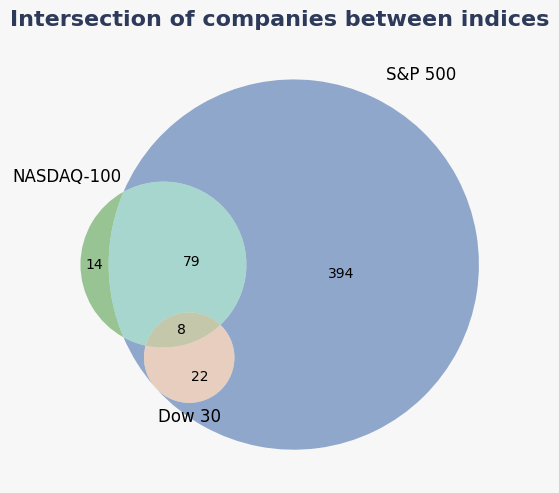

In [46]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

venn = venn3(
    [set(nasdaq100), set(sp500), set(dow30)],
    set_labels=('NASDAQ-100', 'S&P 500', 'Dow 30'),
    set_colors=('#59a14f', '#4c72b0', '#f28e2b'),
    alpha=0.6,
    ax=ax
)

plt.title("Intersection of companies between indices", fontsize=16, fontweight='bold', color='#2e3a59', pad=15)
plt.show()


In [115]:
!"{sys.executable}" -m pip install matplotlib-venn --force-reinstall --no-warn-script-location



  Using cached matplotlib_venn-1.1.2-py3-none-any.whl
  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.3.4-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp311-cp311-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached numpy-2.

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Отказано в доступе: 'c:\\users\\olga\\appdata\\local\\programs\\python\\python311\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
import matplotlib_venn
print("✅ matplotlib-venn загружен успешно")

ModuleNotFoundError: No module named 'matplotlib_venn'

In [117]:
!"{sys.executable}" -m pip install matplotlib-venn --user --upgrade --no-warn-script-location


  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
import site
print(site.USER_SITE)

C:\Users\olga\AppData\Roaming\Python\Python311\site-packages


In [122]:
import sys
sys.path.append(r"C:\Users\olga\AppData\Roaming\Python\Python311\site-packages")

from matplotlib_venn import venn3
print("✅ Всё заработало!")


✅ Всё заработало!


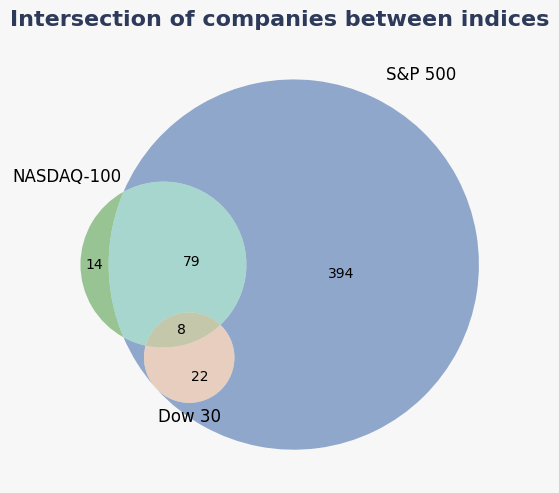

In [47]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

venn = venn3(
    [set(nasdaq100), set(sp500), set(dow30)],
    set_labels=('NASDAQ-100', 'S&P 500', 'Dow 30'),
    set_colors=('#59a14f', '#4c72b0', '#f28e2b'),
    alpha=0.6,
    ax=ax
)

plt.title("Intersection of companies between indices", fontsize=16, fontweight='bold', color='#2e3a59', pad=15)
plt.show()

In [49]:
nasdaq100, sp500, dow30 = get_constituents()  

# Преобразуем в множества для удобства пересечений
set_nq, set_sp, set_dj = set(nasdaq100), set(sp500), set(dow30)

# --- Теперь вычисляем уникальные компании NASDAQ ---
unique_nasdaq = set_nq - (set_sp | set_dj)
print(f"🔹 Уникальные для NASDAQ-100: {len(unique_nasdaq)} компаний\n")
print(sorted(unique_nasdaq))



🔹 Уникальные для NASDAQ-100: 14 компаний

['ALNY', 'ARM', 'ASML', 'CCEP', 'FER', 'INSM', 'MELI', 'MRVL', 'MSTR', 'PDD', 'SHOP', 'TEAM', 'TRI', 'ZS']


In [51]:
import yfinance as yf
import pandas as pd
import numpy as np

# --- 1. Настройки ---
tickers = list(unique_nasdaq)
start_date = "2022-01-01"
end_date = "2025-01-01"

# --- 2. Загрузка данных ---
raw = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', progress=False)

# --- 3. Унификация структуры ---
data = pd.DataFrame()
for t in tickers:
    try:
        if "Adj Close" in raw[t].columns:
            data[t] = raw[t]["Adj Close"]
        elif "Close" in raw[t].columns:
            data[t] = raw[t]["Close"]
    except KeyError:
        print(f"⚠️ Нет данных для {t}, пропускаем.")

# --- 4. Расчёт доходностей ---
returns = data.pct_change().dropna()

# --- 5. Годовые метрики ---
annualized_return = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_volatility

# --- 6. Сводная таблица ---
stats = pd.DataFrame({
    "Annual Return (%)": (annualized_return * 100).round(2),
    "Volatility (%)": (annualized_volatility * 100).round(2),
    "Sharpe Ratio": sharpe_ratio.round(2)
}).sort_values("Annual Return (%)", ascending=False)

# --- 7. Результат ---
print("📊 Annual Return, Risk, and Sharpe Ratio of Unique Nasdaq Companies (2022–2025):")
display(stats)


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\3344647822.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True



📊 Annual Return, Risk, and Sharpe Ratio of Unique Nasdaq Companies (2022–2025):


,Annual Return (%),Volatility (%),Sharpe Ratio
MSTR,214.25,100.79,2.13
INSM,112.90,111.79,1.01
ARM,82.37,81.64,1.01
MRVL,67.00,53.16,1.26
SHOP,54.25,54.01,1.00
FER,30.96,35.23,0.88
ALNY,25.33,46.71,0.54
MELI,22.52,36.00,0.63
TEAM,22.30,46.05,0.48
CCEP,20.39,17.31,1.18


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\4067049245.py:17: FutureWarning:

YF.download() has changed argument auto_adjust default to True

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


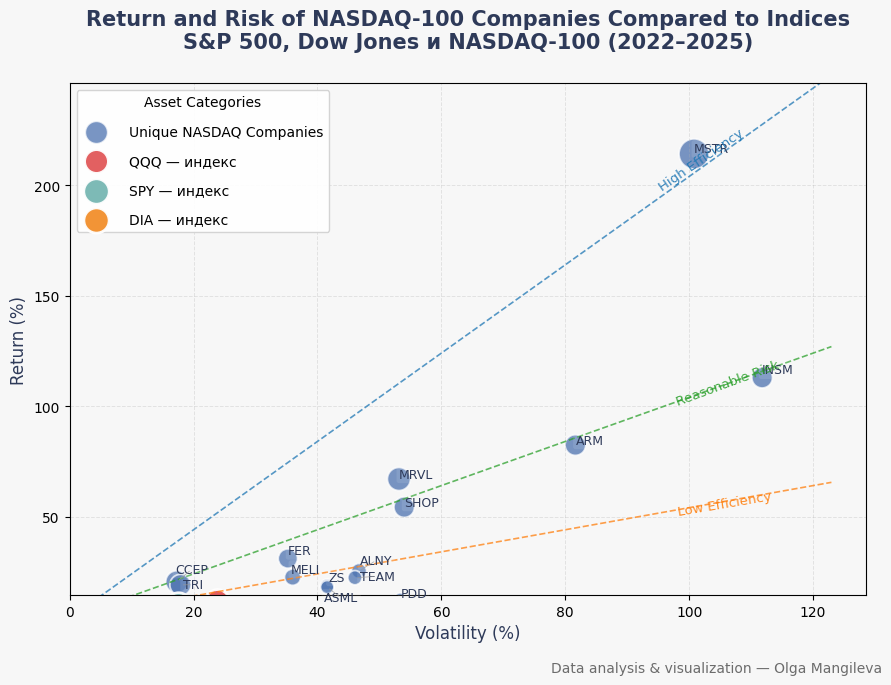

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from adjustText import adjust_text  # если не установлено: pip install adjustText --user

plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

# === 1) Таблица компаний ===
company_stats = stats.copy()

# === 2) Метрики индексов ===
index_tickers = ['QQQ', 'SPY', 'DIA']
raw = yf.download(index_tickers, start="2022-01-01", end="2025-01-01", group_by='ticker', progress=False)

index_data = pd.DataFrame()
for t in index_tickers:
    try:
        if "Adj Close" in raw[t].columns:
            index_data[t] = raw[t]["Adj Close"]
        elif "Close" in raw[t].columns:
            index_data[t] = raw[t]["Close"]
    except KeyError:
        print(f"⚠️ Нет данных для {t}, пропускаем.")

index_returns = index_data.pct_change().dropna()
index_summary = pd.DataFrame({
    'Annual Return (%)': index_returns.mean() * 252 * 100,
    'Volatility (%)': index_returns.std() * np.sqrt(252) * 100
})
index_summary['Sharpe Ratio'] = (index_summary['Annual Return (%)'] / index_summary['Volatility (%)']).round(2)

# === 3) Пузырьки компаний ===
ax.scatter(
    company_stats['Volatility (%)'],
    company_stats['Annual Return (%)'],
    s=company_stats['Sharpe Ratio'] * 220,
    c='#4c72b0',
    alpha=0.75,
    edgecolor='white',
    linewidth=1.3,
    label='Unique NASDAQ Companies'
)

# === 4) Пузырьки индексов (каждый цвет — свой индекс) ===
index_colors = {'QQQ': '#e15759', 'SPY': '#76b7b2', 'DIA': '#f28e2b'}
for ticker, color in index_colors.items():
    x = index_summary.loc[ticker, 'Volatility (%)']
    y = index_summary.loc[ticker, 'Annual Return (%)']
    ax.scatter(
        x, y,
        s=index_summary.loc[ticker, 'Sharpe Ratio'] * 600,
        c=color,
        alpha=0.95,
        edgecolor='white',
        linewidth=2,
        label=f'{ticker} — индекс'
    )

# === 5) Подписи компаний (автоматическое разнесение с выносками) ===
texts = []
for i, ticker in enumerate(company_stats.index):
    x = company_stats["Volatility (%)"].iloc[i]
    y = company_stats["Annual Return (%)"].iloc[i]
    texts.append(ax.text(
        x, y, ticker,
        fontsize=9,
        color='#2e3a59',
        bbox=dict(facecolor=(1, 1, 1, 0.1), edgecolor='none', boxstyle='round,pad=0.2')
    ))

adjust_text(
    texts, 
    ax=ax, 
    arrowprops=dict(arrowstyle='-', color='#999999', lw=0.5, alpha=0.9),
    expand_points=(1.2, 1.4)
)

# === 6) Оформление ===
ax.set_xlim(0, company_stats["Volatility (%)"].max() * 1.15)
ax.set_ylim(company_stats["Annual Return (%)"].min() * 1.1, company_stats["Annual Return (%)"].max() * 1.15)
ax.set_xlabel("Volatility (%)", fontsize=12, color='#2e3a59')
ax.set_ylabel("Return (%)", fontsize=12, color='#2e3a59')

# === 7) Заголовок в две строки ===
ax.set_title(
    "Return and Risk of NASDAQ-100 Companies Compared to Indices\n"
    "S&P 500, Dow Jones и NASDAQ-100 (2022–2025)",
    fontsize=15, fontweight='bold', color='#2e3a59', pad=25, loc='center'
)

ax.grid(alpha=0.3, linestyle='--', linewidth=0.7)

# === 8) Легенда — аккуратно, с описанием индексов ===
legend = ax.legend(
    frameon=True,
    loc='upper left',
    facecolor='white',
    edgecolor='#d0d0d0',
    fontsize=10,
    handletextpad=1.4,
    labelspacing=1.1,
    title="Asset Categories",
    title_fontsize=10
)
legend.get_frame().set_alpha(0.9)

# === 9) Подпись автора ===
ax.text(1.02, -0.15,
        "Data analysis & visualization — Olga Mangileva",
        transform=ax.transAxes, ha='right', fontsize=10, color='#6c6c6c')

# === 10) Линии инфляции и изолинии Шарпа ===
risk_free = 4  # ориентир на инфляцию (в %)
vol_range = np.linspace(0, company_stats["Volatility (%)"].max() * 1.1, 200)

# Горизонтальная линия инфляции
ax.axhline(
    y=risk_free,
    color='#8c564b',
    linestyle='--',
    linewidth=1.3,
    alpha=0.9,
    label='Inflation ~4%'
)

# Изолинии Sharpe (0.5, 1, 2)
sharpe_levels = [0.5, 1, 2]
sharpe_colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
sharpe_labels = ['Low Efficiency', 'Reasonable Risk', 'High Efficiency']

# коэффициенты вращения для ручной подстройки угла
rotation_factors = {0.5: 0.62, 1: 0.7, 2: 0.72}

# индивидуальные смещения по положению (опционально)
offsets = {
    0.5: dict(x=0.8, y=-0.07),
    1: dict(x=0.8, y=-0.12),
    2: dict(x=0.78, y=-0.23)
}

# получаем масштаб осей для расчёта базового угла
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
dx = x1 - x0
dy = y1 - y0

for s, color, desc in zip(sharpe_levels, sharpe_colors, sharpe_labels):
    y_vals = risk_free + s * vol_range
    ax.plot(vol_range, y_vals, color=color, linestyle='--', linewidth=1.2, alpha=0.75, label=f'Sharpe = {s}')

    # базовый угол с учётом масштаба
    base_angle = np.degrees(np.arctan((s * dx) / dy))
    # применяем твой кастомный множитель
    angle = base_angle * rotation_factors.get(s, 1.0)

    # извлекаем координаты смещения
    pos = offsets[s]
    ax.text(
        vol_range[-1] * pos['x'],
        y_vals[-1] + pos['y'] * dy,
        desc,
        color=color,
        fontsize=9.5,
        rotation=angle,
        rotation_mode='anchor',
        ha='left',
        va='bottom',
        alpha=0.9
    )


plt.tight_layout()
plt.show()


In [53]:
!pip install --user adjustText



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\olga\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [55]:
import yfinance as yf
import pandas as pd
import numpy as np

# --- 1) Список уникальных компаний ---
unique_nasdaq = ['ARM', 'ASML', 'AZN', 'CCEP', 'GFS', 'MELI', 'MRVL', 
                 'MSTR', 'PDD', 'SHOP', 'TEAM', 'TRI', 'ZS']

start_date = "2022-01-01"
end_date = "2025-01-01"

# --- 2) Загрузка данных по ценам и дивидендам ---
price_data = yf.download(unique_nasdaq, start=start_date, end=end_date, group_by='ticker', progress=False)

dividends = {}
for ticker in unique_nasdaq:
    try:
        div = yf.Ticker(ticker).dividends
        div_period = div.loc[start_date:end_date]
        dividends[ticker] = div_period.sum()
    except Exception as e:
        print(f"⚠️ Пропущено {ticker}: {e}")
        dividends[ticker] = 0.0

dividends = pd.Series(dividends, name="Total Dividends ($)")

# --- 3) Расчёт доходности и дивидендной доходности ---
returns = {}
for ticker in unique_nasdaq:
    try:
        # Извлекаем цены закрытия (fallback: 'Close')
        close = price_data[ticker]["Adj Close"] if "Adj Close" in price_data[ticker] else price_data[ticker]["Close"]
        price_return = (close.iloc[-1] - close.iloc[0]) / close.iloc[0] * 100
        div_yield = dividends[ticker] / close.iloc[0] * 100
        total_return = price_return + div_yield
        returns[ticker] = {
            "Price Return (%)": round(price_return, 2),
            "Dividend Yield (%)": round(div_yield, 2),
            "Total Return (%)": round(total_return, 2)
        }
    except Exception as e:
        print(f"⚠️ Ошибка для {ticker}: {e}")

returns_df = pd.DataFrame(returns).T.sort_values("Total Return (%)", ascending=False)

# --- 4) Результаты ---
print("📈 Доходность с учётом дивидендов (2022–2025):")
display(returns_df)


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\2556480553.py:13: FutureWarning:

YF.download() has changed argument auto_adjust default to True



📈 Доходность с учётом дивидендов (2022–2025):


,Price Return (%),Dividend Yield (%),Total Return (%)
MSTR,418.79,0.00,418.79
PDD,72.89,0.00,72.89
CCEP,49.71,11.60,61.31
TRI,43.08,9.90,52.97
AZN,20.00,8.29,28.29
MELI,27.57,0.00,27.57
MRVL,25.13,0.82,25.94
ASML,-10.43,2.59,-7.85
SHOP,-22.00,0.00,-22.00
TEAM,-30.55,0.00,-30.55


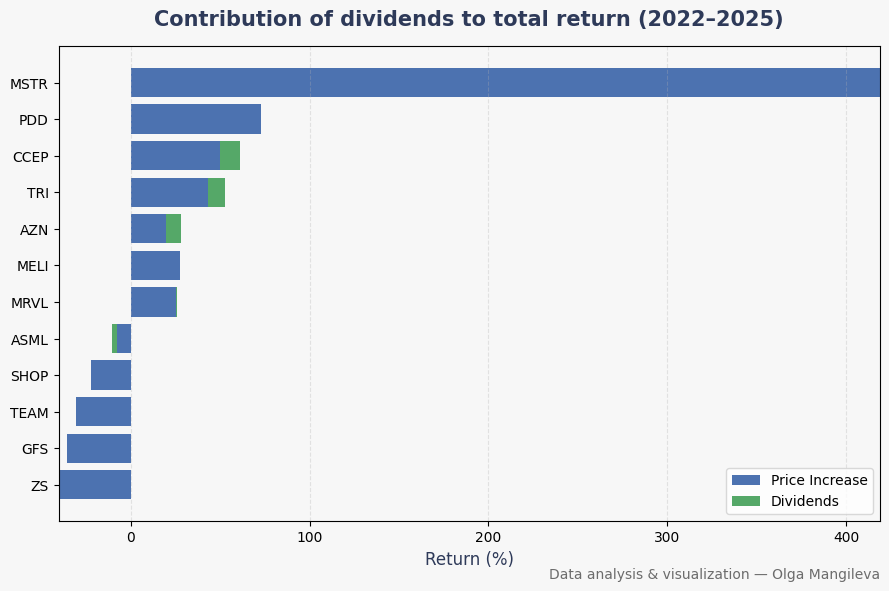

In [57]:
import matplotlib.pyplot as plt

# Фильтруем корректные данные
plot_df = returns_df.dropna().sort_values("Total Return (%)", ascending=True)

# Создаём фигуру
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

# Столбцы доходности
ax.barh(plot_df.index, plot_df["Price Return (%)"], color='#4c72b0', label="Price Increase")
ax.barh(plot_df.index, plot_df["Dividend Yield (%)"],
        left=plot_df["Price Return (%)"], color='#55a868', label="Dividends")

# Подписи и оформление
ax.set_title("Contribution of dividends to total return (2022–2025)",
             fontsize=15, fontweight='bold', color='#2e3a59', pad=15)
ax.set_xlabel("Return (%)", fontsize=12, color='#2e3a59')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='#d0d0d0')

# Подпись автора
ax.text(1.0, -0.12, "Data analysis & visualization — Olga Mangileva",
        transform=ax.transAxes, ha='right', fontsize=10, color='#6c6c6c')

plt.tight_layout()
plt.show()


In [205]:
# --- Пересчёт коэффициентов Sharpe с учётом дивидендов ---

# Риск (волатильность) оставляем прежний — из company_stats
sharpe_total = company_stats[['Volatility (%)']].copy()

# Добавляем новую total return (из returns_df)
sharpe_total['Total Return (%)'] = returns_df['Total Return (%)']

# Очищаем NaN
sharpe_total = sharpe_total.dropna()

# Безрисковая ставка (инфляция)
risk_free = 4  

# Sharpe ratio = (R - Rf) / σ
sharpe_total['Sharpe (Total Return)'] = (
    (sharpe_total['Total Return (%)'] - risk_free) / sharpe_total['Volatility (%)']
).round(2)

# Сортировка по эффективности
sharpe_total = sharpe_total.sort_values('Sharpe (Total Return)', ascending=False)

print("📊 Коэффициенты Шарпа с учётом дивидендов:")
display(sharpe_total)


📊 Коэффициенты Шарпа с учётом дивидендов:


,Volatility (%),Total Return (%),Sharpe (Total Return)
MSTR,100.79,418.79,4.12
CCEP,17.31,61.13,3.30
TRI,17.89,52.85,2.73
PDD,53.33,72.89,1.29
AZN,20.82,28.21,1.16
MELI,36.00,27.57,0.65
MRVL,53.16,25.94,0.41
ASML,41.58,-7.85,-0.28
SHOP,54.01,-22.00,-0.48
TEAM,46.05,-30.55,-0.75


C:\Users\olga\AppData\Local\Temp\ipykernel_154544\1646338012.py:18: FutureWarning:

YF.download() has changed argument auto_adjust default to True



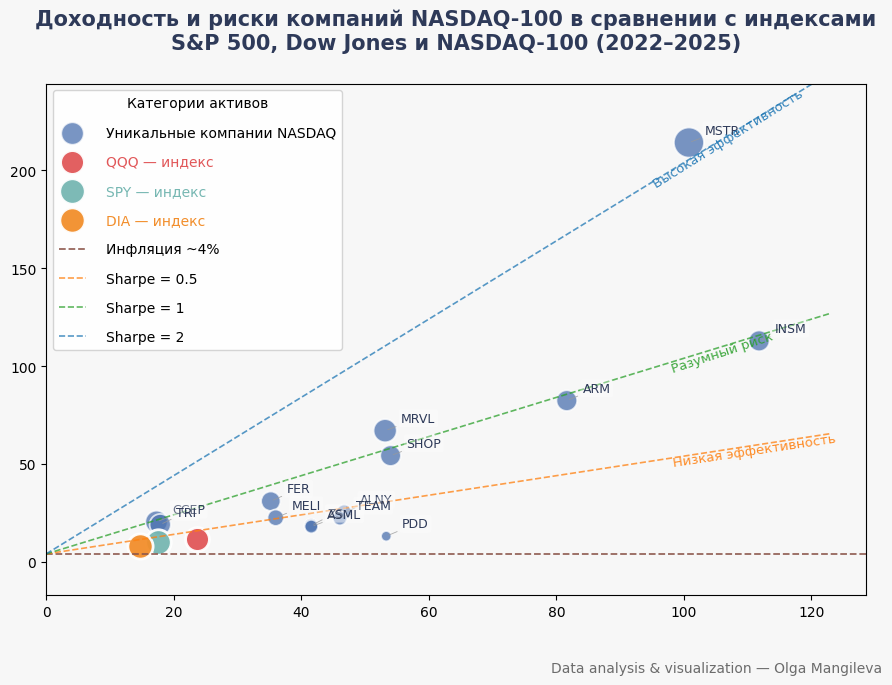

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

plt.style.use('seaborn-v0_8-muted')

# === 1) Подготовка графика ===
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

# === 2) Таблица компаний ===
company_stats = stats.copy()

# === 3) Метрики индексов ===
index_tickers = ['QQQ', 'SPY', 'DIA']
raw = yf.download(index_tickers, start="2022-01-01", end="2025-01-01",
                  group_by='ticker', progress=False)

index_data = pd.DataFrame()
for t in index_tickers:
    try:
        if "Adj Close" in raw[t].columns:
            index_data[t] = raw[t]["Adj Close"]
        elif "Close" in raw[t].columns:
            index_data[t] = raw[t]["Close"]
    except KeyError:
        print(f"⚠️ Нет данных для {t}, пропускаем.")

index_returns = index_data.pct_change().dropna()
index_summary = pd.DataFrame({
    'Annual Return (%)': index_returns.mean() * 252 * 100,
    'Volatility (%)': index_returns.std() * np.sqrt(252) * 100
})
index_summary['Sharpe Ratio'] = (
    index_summary['Annual Return (%)'] / index_summary['Volatility (%)']
).round(2)

# === 4) Пузырьки компаний ===
ax.scatter(
    company_stats['Volatility (%)'],
    company_stats['Annual Return (%)'],
    s=company_stats['Sharpe Ratio'] * 220,
    c='#4c72b0',
    alpha=0.75,
    edgecolor='white',
    linewidth=1.3,
    label='Уникальные компании NASDAQ'
)

# === 5) Пузырьки индексов (каждый цвет — свой индекс) ===
index_colors = {'QQQ': '#e15759', 'SPY': '#76b7b2', 'DIA': '#f28e2b'}
for ticker, color in index_colors.items():
    x = index_summary.loc[ticker, 'Volatility (%)']
    y = index_summary.loc[ticker, 'Annual Return (%)']
    ax.scatter(
        x, y,
        s=index_summary.loc[ticker, 'Sharpe Ratio'] * 600,
        c=color,
        alpha=0.95,
        edgecolor='white',
        linewidth=2,
        label=f'{ticker} — индекс'
    )

# === 6) Подписи компаний — через annotate, с контролируемыми смещениями ===
dx, dy = 2.5, 3.0  # ← базовые смещения по осям X и Y (можно менять)
for i, ticker in enumerate(company_stats.index):
    x = company_stats["Volatility (%)"].iloc[i]
    y = company_stats["Annual Return (%)"].iloc[i]
    ax.annotate(
        ticker,
        xy=(x, y),  # центр пузырька
        xytext=(x + dx, y + dy),  # позиция подписи со смещением
        textcoords='data',
        fontsize=9,
        color='#2e3a59',
        ha='left',
        va='bottom',
        bbox=dict(facecolor=(1, 1, 1, 0.3),
                  edgecolor='none',
                  boxstyle='round,pad=0.2'),
        arrowprops=dict(
            arrowstyle='-',
            color='#999999',
            lw=0.6,
            alpha=0.8
        )
    )

# === Корректное масштабирование осей ===
x_min = 0
x_max = company_stats["Volatility (%)"].max() * 1.15

y_min_real = np.nanmin(company_stats["Annual Return (%)"])
y_max_real = np.nanmax(company_stats["Annual Return (%)"])
y_range = y_max_real - y_min_real

# добавляем "воздух" сверху и снизу
y_min = y_min_real - 0.15 * y_range
y_max = y_max_real + 0.15 * y_range

# проверка: если всё равно min > max, меняем местами (на случай NaN)
if y_min >= y_max:
    y_min, y_max = sorted([y_min_real, y_max_real])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)



# === 8) Заголовок ===
ax.set_title(
    "Доходность и риски компаний NASDAQ-100 в сравнении с индексами\n"
    "S&P 500, Dow Jones и NASDAQ-100 (2022–2025)",
    fontsize=15, fontweight='bold', color='#2e3a59', pad=25, loc='center'
)

# === 9) Линии инфляции и изолинии Шарпа ===
risk_free = 4  # базовый уровень
vol_range = np.linspace(0, company_stats["Volatility (%)"].max() * 1.1, 200)

ax.axhline(y=risk_free, color='#8c564b', linestyle='--',
           linewidth=1.3, alpha=0.9, label='Инфляция ~4%')

sharpe_levels = [0.5, 1, 2]
sharpe_colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
sharpe_labels = ['Низкая эффективность', 'Разумный риск', 'Высокая эффективность']

rotation_factors = {0.5: 0.62, 1: 0.7, 2: 0.72}
offsets = {0.5: dict(x=0.8, y=-0.07),
           1: dict(x=0.8, y=-0.12),
           2: dict(x=0.78, y=-0.23)}

x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
dx_axis = x1 - x0
dy_axis = y1 - y0

for s, color, desc in zip(sharpe_levels, sharpe_colors, sharpe_labels):
    y_vals = risk_free + s * vol_range
    ax.plot(vol_range, y_vals, color=color, linestyle='--',
            linewidth=1.2, alpha=0.75, label=f'Sharpe = {s}')

    base_angle = np.degrees(np.arctan((s * dx_axis) / dy_axis))
    angle = base_angle * rotation_factors.get(s, 1.0)
    pos = offsets[s]
    ax.text(vol_range[-1] * pos['x'],
            y_vals[-1] + pos['y'] * dy_axis,
            desc, color=color, fontsize=9.5,
            rotation=angle, rotation_mode='anchor',
            ha='left', va='bottom', alpha=0.9)

# === 10) Легенда ===
legend = ax.legend(
    frameon=True,
    loc='upper left',
    facecolor=(1, 1, 1, 0.85),
    edgecolor='#d0d0d0',
    fontsize=10,
    handletextpad=1.4,
    labelspacing=1.1,
    title="Категории активов",
    title_fontsize=10
)
for text, color in zip(legend.get_texts()[1:], ['#e15759', '#76b7b2', '#f28e2b']):
    text.set_color(color)
legend.get_frame().set_alpha(0.9)

# === 11) Подпись автора ===
ax.text(1.02, -0.15,
        "Data analysis & visualization — Olga Mangileva",
        transform=ax.transAxes, ha='right', fontsize=10, color='#6c6c6c')

plt.tight_layout()
plt.show()


In [215]:
# допустим, у тебя есть DataFrame с дивидендами:
# columns = ['Price Return (%)', 'Dividend Yield (%)', 'Total Return (%)']

div_df = pd.DataFrame({
    'Price Return (%)': [418.79, 72.89, 49.71, 43.08, 20.00, 27.57, 25.13, -10.43, -22.00, -30.55, -35.70, -40.23, np.nan],
    'Dividend Yield (%)': [0.00, 0.00, 11.42, 9.78, 8.20, 0.00, 0.82, 2.58, 0.00, 0.00, 0.00, 0.00, np.nan],
    'Total Return (%)': [418.79, 72.89, 61.13, 52.85, 28.21, 27.57, 25.94, -7.85, -22.00, -30.55, -35.70, -40.23, np.nan]
}, index=['MSTR','PDD','CCEP','TRI','AZN','MELI','MRVL','ASML','SHOP','TEAM','GFS','ZS','ARM'])

# потом мёржим с company_stats
company_stats = company_stats.join(div_df[['Total Return (%)']], how='left')


In [216]:
print(company_stats[['Volatility (%)', 'Annual Return (%)', 'Total Return (%)']])



      Volatility (%)  Annual Return (%)  Total Return (%)
MSTR          100.79             214.25            418.79
ARM            81.64              82.37               NaN
MRVL           53.16              67.00             25.94
SHOP           54.01              54.25            -22.00
MELI           36.00              22.52             27.57
TEAM           46.05              22.30            -30.55
CCEP           17.31              20.39             61.13
TRI            17.89              19.00             52.85
ZS             41.56              18.55            -40.23
ASML           41.58              17.98             -7.85
PDD            53.33              13.07             72.89
AZN            20.82               1.21             28.21
GFS            41.96             -18.20            -35.70


C:\Users\olga\AppData\Local\Temp\ipykernel_36056\2893390728.py:32: FutureWarning:

YF.download() has changed argument auto_adjust default to True



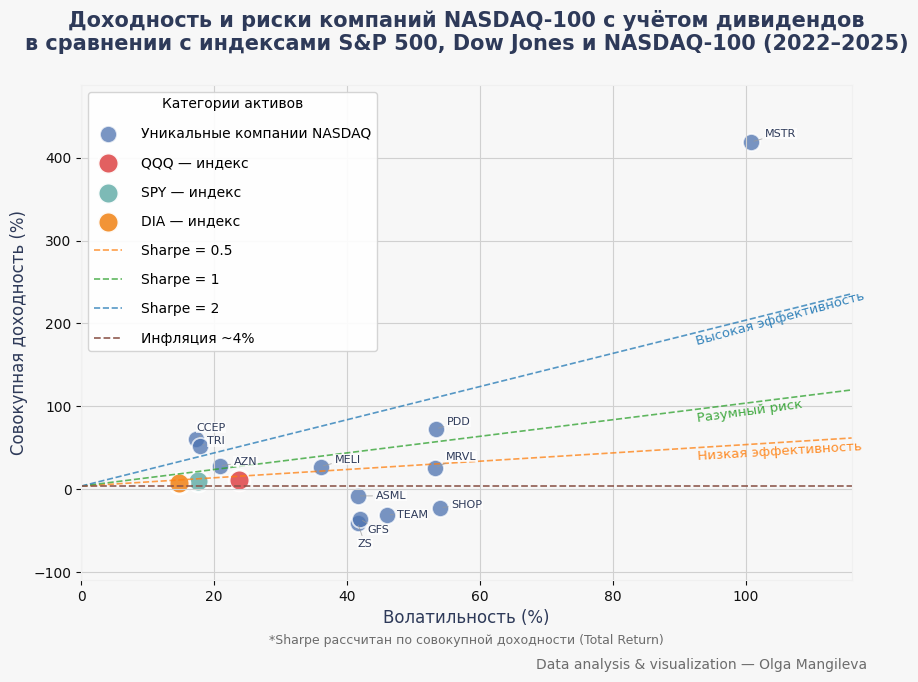

In [252]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from adjustText import adjust_text

plt.style.use('seaborn-v0_8-muted')
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

# === 1) Таблица компаний (исходная) ===
company_stats = stats.copy()

# === 2) Добавляем дивиденды и совокупную доходность ===
div_df = pd.DataFrame({
    'Price Return (%)': [418.79, 72.89, 49.71, 43.08, 20.00, 27.57, 25.13, -10.43, -22.00, -30.55, -35.70, -40.23, np.nan],
    'Dividend Yield (%)': [0.00, 0.00, 11.42, 9.78, 8.20, 0.00, 0.82, 2.58, 0.00, 0.00, 0.00, 0.00, np.nan],
    'Total Return (%)': [418.79, 72.89, 61.13, 52.85, 28.21, 27.57, 25.94, -7.85, -22.00, -30.55, -35.70, -40.23, np.nan]
}, index=['MSTR','PDD','CCEP','TRI','AZN','MELI','MRVL','ASML','SHOP','TEAM','GFS','ZS','ARM'])

# объединяем с company_stats
company_stats = company_stats.join(div_df[['Total Return (%)']], how='left')

# === 3) Пересчитываем Sharpe по совокупной доходности ===
risk_free = 4  # инфляция / безрисковая ставка
company_stats['Sharpe Ratio'] = ((company_stats['Total Return (%)'] - risk_free) /
                                 company_stats['Volatility (%)']).round(2)

# === 4) Индексы (QQQ, SPY, DIA) ===
index_tickers = ['QQQ', 'SPY', 'DIA']
raw = yf.download(index_tickers, start="2022-01-01", end="2025-01-01",
                  group_by='ticker', progress=False)

index_data = pd.DataFrame()
for t in index_tickers:
    try:
        if "Adj Close" in raw[t].columns:
            index_data[t] = raw[t]["Adj Close"]
        elif "Close" in raw[t].columns:
            index_data[t] = raw[t]["Close"]
    except KeyError:
        print(f"⚠️ Нет данных для {t}, пропускаем.")

index_returns = index_data.pct_change().dropna()
index_summary = pd.DataFrame({
    'Annual Return (%)': index_returns.mean() * 252 * 100,
    'Volatility (%)': index_returns.std() * np.sqrt(252) * 100
})
index_summary['Sharpe Ratio'] = ((index_summary['Annual Return (%)'] - risk_free) /
                                 index_summary['Volatility (%)']).round(2)

# === 5) Построение пузырьков ===
# Все пузыри одинакового размера
bubble_size = 150

ax.scatter(
    company_stats['Volatility (%)'],
    company_stats['Total Return (%)'],
    s=bubble_size,
    c='#4c72b0',
    alpha=0.75,
    edgecolor='white',
    linewidth=1.3,
    label='Уникальные компании NASDAQ'
)

# Индексы (тоже стандартного размера, но чуть больше)
index_colors = {'QQQ': '#e15759', 'SPY': '#76b7b2', 'DIA': '#f28e2b'}
for ticker, color in index_colors.items():
    x = index_summary.loc[ticker, 'Volatility (%)']
    y = index_summary.loc[ticker, 'Annual Return (%)']
    ax.scatter(
        x, y,
        s=bubble_size * 1.5,
        c=color,
        alpha=0.95,
        edgecolor='white',
        linewidth=2,
        label=f'{ticker} — индекс'
    )


# === 6) Подписи ===
# === 6) Подписи с индивидуальными офсетами и выносками ===

# словарь индивидуальных смещений: { 'тикер': (смещение_X, смещение_Y) }
label_offsets = {
    'MSTR': (10, 6),
    'PDD': (8, 5),
    'CCEP': (0, 8),
    'TRI': (5, 3),
    'AZN': (10, 3),
    'MELI': (10, 5),
    'MRVL': (8, 8),
    'ASML': (13, 0),
    'SHOP': (8, 2),
    'TEAM': (7, 0),
    'GFS': (5, -8),
    'ZS': (0, -15),
    'ARM': (8, 6)
}

for i, ticker in enumerate(company_stats.index):
    x = company_stats["Volatility (%)"].iloc[i]
    y = company_stats["Total Return (%)"].iloc[i]
    dx, dy = label_offsets.get(ticker, (5, 3))  # если офсет не указан — стандартный

    ax.annotate(
        ticker,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=8,
        color='#2e3a59',
        ha='left',
        va='center',
        bbox=dict(facecolor='white', edgecolor='none', pad=0.2, alpha=0.7),
        arrowprops=dict(
            arrowstyle='-', color='#999999', lw=0.6, alpha=0.8
        )
    )


# === 7) Масштаб осей (корректный с отрицательными значениями) ===
x_min = 0
x_max = company_stats["Volatility (%)"].max() * 1.15

y_min_real = np.nanmin(company_stats["Total Return (%)"])
y_max_real = np.nanmax(company_stats["Total Return (%)"])
y_range = y_max_real - y_min_real
y_min = y_min_real - 0.15 * y_range
y_max = y_max_real + 0.15 * y_range
if y_min >= y_max:
    y_min, y_max = sorted([y_min_real, y_max_real])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Волатильность (%)", fontsize=12, color='#2e3a59')
ax.set_ylabel("Совокупная доходность (%)", fontsize=12, color='#2e3a59')

# === 8) Линии Sharpe ===
vol_range = np.linspace(0, x_max, 200)
sharpe_levels = [0.5, 1, 2]
sharpe_colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
sharpe_labels = ['Низкая эффективность', 'Разумный риск', 'Высокая эффективность']

# индивидуальные коэффициенты поворота и смещения
rotation_factors = {0.5: 0.62, 1: 0.7, 2: 0.72}
offsets = {
    0.5: dict(x=0.8, y=-0.05),
    1: dict(x=0.8, y=-0.07),
    2: dict(x=0.8, y=-0.11)
}

x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
dx = x1 - x0
dy = y1 - y0

for s, color, desc in zip(sharpe_levels, sharpe_colors, sharpe_labels):
    y_vals = risk_free + s * vol_range
    ax.plot(vol_range, y_vals, color=color, linestyle='--', linewidth=1.2, alpha=0.75, label=f'Sharpe = {s}')

    base_angle = np.degrees(np.arctan((s * dx) / dy))
    angle = base_angle * rotation_factors.get(s, 1.0)

    pos = offsets[s]
    ax.text(
        vol_range[-1] * pos['x'],
        y_vals[-1] + pos['y'] * dy,
        desc,
        color=color,
        fontsize=9.5,
        rotation=angle,
        rotation_mode='anchor',
        ha='left',
        va='bottom',
        alpha=0.9
    )

# Линия инфляции
ax.axhline(y=risk_free, color='#8c564b', linestyle='--', linewidth=1.3, alpha=0.9, label='Инфляция ~4%')


# === 9) Легенда ===
legend = ax.legend(frameon=True, loc='upper left', facecolor='white',
                   edgecolor='#d0d0d0', fontsize=10, handletextpad=1.4,
                   labelspacing=1.1, title="Категории активов", title_fontsize=10)
legend.get_frame().set_alpha(0.9)

# === 10) Заголовок и подпись ===
ax.set_title("Доходность и риски компаний NASDAQ-100 с учётом дивидендов\n"
             "в сравнении с индексами S&P 500, Dow Jones и NASDAQ-100 (2022–2025)",
             fontsize=15, fontweight='bold', color='#2e3a59', pad=25, loc='center')

ax.text(0.5, -0.13, "*Sharpe рассчитан по совокупной доходности (Total Return)",
        transform=ax.transAxes, ha='center', fontsize=9, color='#6c6c6c')

ax.text(1.02, -0.18, "Data analysis & visualization — Olga Mangileva",
        transform=ax.transAxes, ha='right', fontsize=10, color='#6c6c6c')

plt.tight_layout()
plt.show()


2025-11-11 15:59:23.241 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.245 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.245 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.247 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-11 15:59:23.250 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

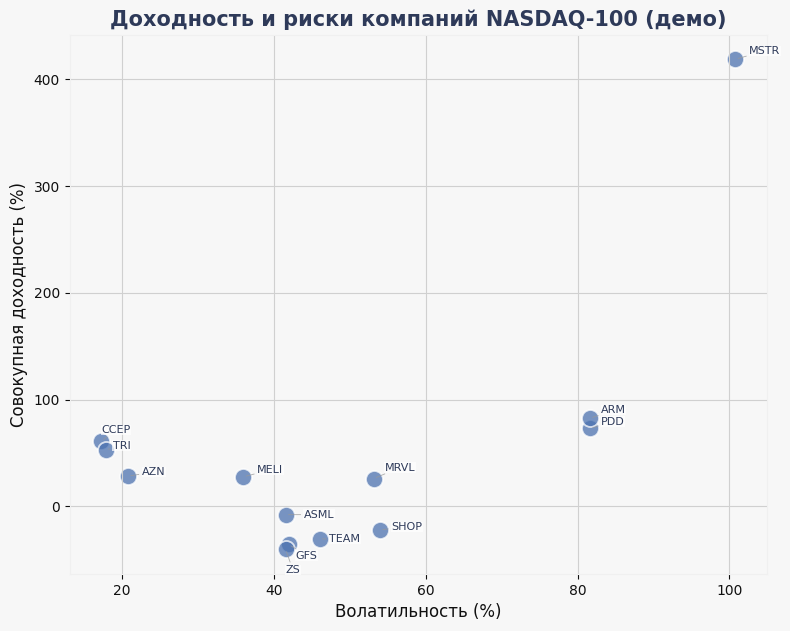

In [262]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="NASDAQ-100 Bubble Chart", layout="wide")

# === 1) Данные ===
company_stats = pd.DataFrame({
    "Volatility (%)": [100.79, 81.64, 17.31, 17.89, 20.82, 36.00, 53.16, 41.58, 54.01, 46.05, 41.96, 41.56, 81.64],
    "Total Return (%)": [418.79, 72.89, 61.13, 52.85, 28.21, 27.57, 25.94, -7.85, -22.00, -30.55, -35.70, -40.23, 82.37]
}, index=['MSTR','PDD','CCEP','TRI','AZN','MELI','MRVL','ASML','SHOP','TEAM','GFS','ZS','ARM'])

label_offsets = pd.DataFrame({
    "Ticker": ['MSTR','PDD','CCEP','TRI','AZN','MELI','MRVL','ASML','SHOP','TEAM','GFS','ZS','ARM'],
    "Offset X": [10, 8, 0, 5, 10, 10, 8, 13, 8, 7, 5, 0, 8],
    "Offset Y": [6, 5, 8, 3, 3, 5, 8, 0, 2, 0, -8, -15, 6]
}).set_index("Ticker")

# === 2) Интерфейс Streamlit ===
st.sidebar.title("⚙️ Настройки подписи")

tickers = company_stats.index.tolist()
selected_ticker = st.sidebar.selectbox("Выбери компанию:", tickers)

dx_default = int(label_offsets.loc[selected_ticker, "Offset X"]) if selected_ticker in label_offsets.index else 0
dy_default = int(label_offsets.loc[selected_ticker, "Offset Y"]) if selected_ticker in label_offsets.index else 0

dx = st.sidebar.slider("Смещение по X", -20, 20, dx_default)
dy = st.sidebar.slider("Смещение по Y", -20, 20, dy_default)

# обновляем значения оффсета
label_offsets.loc[selected_ticker, "Offset X"] = dx
label_offsets.loc[selected_ticker, "Offset Y"] = dy

# === 3) Построение пузырьковой диаграммы ===
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#f7f7f7')
fig.patch.set_facecolor('#f7f7f7')

bubble_size = 150
ax.scatter(
    company_stats['Volatility (%)'],
    company_stats['Total Return (%)'],
    s=bubble_size,
    c='#4c72b0',
    alpha=0.75,
    edgecolor='white',
    linewidth=1.3
)

# подписи с индивидуальными смещениями
for ticker, row in company_stats.iterrows():
    x = row["Volatility (%)"]
    y = row["Total Return (%)"]
    dx = label_offsets.loc[ticker, "Offset X"]
    dy = label_offsets.loc[ticker, "Offset Y"]
    ax.annotate(
        ticker,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=8,
        color='#2e3a59',
        ha='left',
        va='center',
        bbox=dict(facecolor='white', edgecolor='none', pad=0.2, alpha=0.7),
        arrowprops=dict(arrowstyle='-', color='#999999', lw=0.6, alpha=0.8)
    )

ax.set_xlabel("Волатильность (%)", fontsize=12)
ax.set_ylabel("Совокупная доходность (%)", fontsize=12)
ax.set_title("Доходность и риски компаний NASDAQ-100 (демо)", fontsize=15, fontweight='bold', color='#2e3a59')

st.pyplot(fig)

# === 4) Таблица оффсетов (для сохранения) ===
st.subheader("🧭 Текущие смещения подписей")
st.dataframe(label_offsets.style.format({"Offset X": "{:+}", "Offset Y": "{:+}"}))

st.success("Готово! Можешь менять оффсеты в боковой панели — график будет обновляться сразу.")



In [255]:
!pip install streamlit



     ---------------------------------------- 0.0/44.3 kB ? eta -:--:--
     --------------------------- ------------ 30.7/44.3 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 44.3/44.3 kB 540.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/10.2 MB 3.2 MB/s eta 0:00:04
   ---------------------------------------- 0.1/10.2 MB 3.2 MB/s eta 0:00:04
   ---------------------------------------- 0.1/10.2 MB 901.1 kB/s eta 0:00:12
    --------------------------------------- 0.2/10.2 MB 762.6 kB/s eta 0:00:14
   - -------------------------------------- 0.3/10.2 MB 1.2 MB/s eta 0:00:09
   - -------------------------------------- 0.4/10.2 MB 1.3 MB/s eta 0:00:08
   - -------------------------------------- 0.5/10.2 MB 1.6 MB/s eta 0:00:07
   -- ------------------------------------- 0.6/10.2 MB 1.6 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/10.2 MB 1.8 MB/s eta 0:00:06
 


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [258]:
company_stats.to_csv("company_stats.csv", index=False)


In [1]:
pd.DataFrame.from_dict(label_offsets, orient='index', columns=['Offset X', 'Offset Y']).to_csv("label_offsets.csv")


NameError: name 'pd' is not defined

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# Наш набор тикеров (уникальные для NASDAQ-100)
TICKERS = ['MSTR','PDD','CCEP','TRI','AZN','MELI','MRVL','ASML','SHOP','TEAM','GFS','ZS','ARM']

def get_info_safe(ticker):
    t = yf.Ticker(ticker)
    # пробуем новый API, если нет — старый .info
    try:
        info = t.get_info()
    except Exception:
        info = getattr(t, "info", {})
    if info is None:
        info = {}
    return info

def map_reco_to_1_5(key: str | None, mean: float | None):
    """
    yfinance даёт либо recommendationKey (strong_buy / buy / hold / sell / strong_sell),
    либо recommendationMean (1–5).
    Нам нужно 1–5, где 1 = Strong Sell, 5 = Strong Buy.
    """
    # если уже есть нормальное число
    if mean is not None and not pd.isna(mean):
        # у yfinance 1=Strong Buy, 5=Sell
        # а мы хотим наоборот: 1=Strong Sell, 5=Strong Buy
        return round(6 - float(mean), 2)

    if not key:
        return np.nan

    key = key.lower()
    mapping = {
        "strong_buy": 5.0,
        "buy": 4.0,
        "hold": 3.0,
        "sell": 2.0,
        "strong_sell": 1.0,
    }
    return mapping.get(key, np.nan)

rows = []

for ticker in TICKERS:
    print(f"⚙️ Загружаю данные по {ticker}...")
    info = get_info_safe(ticker)

    current_price = info.get("currentPrice") or info.get("regularMarketPrice")
    target_mean = info.get("targetMeanPrice")

    if current_price and target_mean:
        target_upside = (target_mean / current_price - 1.0) * 100
    else:
        target_upside = np.nan

    analyst_rating = map_reco_to_1_5(
        info.get("recommendationKey"),
        info.get("recommendationMean"),
    )

    row = {
        "Ticker": ticker,
        "Sector": info.get("sector"),
        "MarketCap (B)": (info.get("marketCap") or np.nan) / 1e9,
        "PE": info.get("trailingPE"),
        "ForwardPE": info.get("forwardPE"),
        "PEG": info.get("pegRatio"),
        "EV_EBITDA": info.get("enterpriseToEbitda"),
        # роста «за 5 лет» у yfinance нет, берём то, что есть как приближение
        "EPS_Growth_5Y (%)": (info.get("earningsGrowth") or 0) * 100 if info.get("earningsGrowth") is not None else np.nan,
        "Revenue_Growth_5Y (%)": (info.get("revenueGrowth") or 0) * 100 if info.get("revenueGrowth") is not None else np.nan,
        "Debt_to_Equity": info.get("debtToEquity"),
        "ProfitMargin (%)": (info.get("profitMargins") or 0) * 100 if info.get("profitMargins") is not None else np.nan,
        "ROE (%)": (info.get("returnOnEquity") or 0) * 100 if info.get("returnOnEquity") is not None else np.nan,
        "AnalystRating": analyst_rating,
        "TargetPriceUpside (%)": target_upside,
    }

    rows.append(row)

df = pd.DataFrame(rows)

# лёгкая чистка/округление
num_cols = [
    "MarketCap (B)", "PE", "ForwardPE", "PEG", "EV_EBITDA",
    "EPS_Growth_5Y (%)", "Revenue_Growth_5Y (%)",
    "Debt_to_Equity", "ProfitMargin (%)", "ROE (%)",
    "AnalystRating", "TargetPriceUpside (%)"
]
df[num_cols] = df[num_cols].astype(float).round(2)

print("\n✅ Итоговый DataFrame:")
print(df)

# сохраняем в нужное место
output_path = "data/fundamentals.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\n💾 Обновлённые фундаментальные данные сохранены в {output_path}")


⚙️ Загружаю данные по MSTR...
⚙️ Загружаю данные по PDD...
⚙️ Загружаю данные по CCEP...
⚙️ Загружаю данные по TRI...
⚙️ Загружаю данные по AZN...
⚙️ Загружаю данные по MELI...
⚙️ Загружаю данные по MRVL...
⚙️ Загружаю данные по ASML...
⚙️ Загружаю данные по SHOP...
⚙️ Загружаю данные по TEAM...
⚙️ Загружаю данные по GFS...
⚙️ Загружаю данные по ZS...
⚙️ Загружаю данные по ARM...

✅ Итоговый DataFrame:
   Ticker              Sector  MarketCap (B)      PE  ForwardPE  PEG  \
0    MSTR          Technology          52.11    7.45    -421.70  NaN   
1     PDD   Consumer Cyclical         168.80   12.19       8.44  NaN   
2    CCEP  Consumer Defensive          41.55   23.89      20.32  NaN   
3     TRI         Industrials          60.26   34.36      33.16  NaN   
4     AZN          Healthcare         279.58   29.96      16.42  NaN   
5    MELI   Consumer Cyclical         107.27   51.54      43.74  NaN   
6    MRVL          Technology          80.09   32.71      37.16  NaN   
7    ASML         

OSError: Cannot save file into a non-existent directory: 'data'